In [1]:
import os
print(os.environ.get('CONDA_DEFAULT_ENV'))
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import torch
import sys



/projectnb/paxlab/presh/env/conda_env/mosaicfield_env


In [2]:
sys.path.append(os.path.abspath("/projectnb/paxlab/presh/software/MOSAICField/src/MOSAICField"))
sys.path.append(os.path.abspath("/projectnb/paxlab/presh/software/MOSAICField"))
from src.MOSAICField.affine_alignment import affine_align
from src.MOSAICField.nonlinear_alignment import warp_image, warp_image_reverse, nonlinear_align

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from types import SimpleNamespace
import anndata as ad
import os


STEP 0: Loading affine-aligned objects

Source (ATAC): (11640, 2000)
Target (Xenium): (61151, 380)
Source coords: x=[-3896.5, 3848.2]
Target coords: x=[-4051.4, 3508.3]


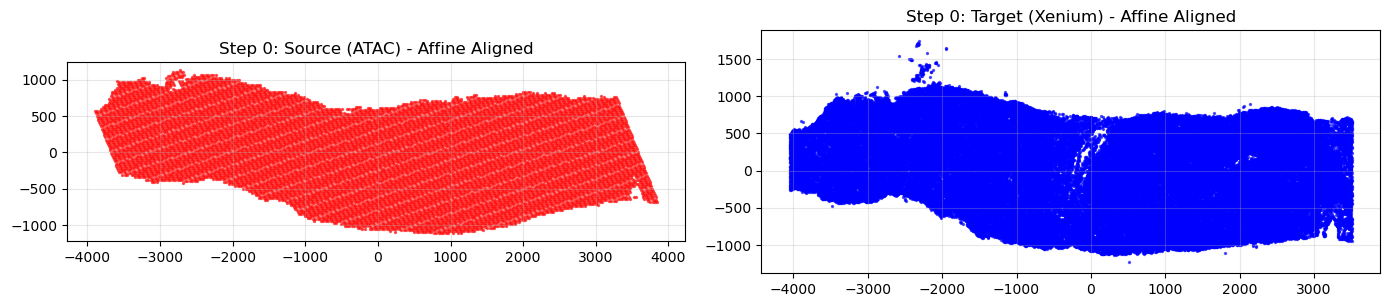

✓ Saved step0_affine_aligned.png



In [4]:
# ============================================================================
# STEP 0: LOAD AFFINE-ALIGNED OBJECTS
# ============================================================================

print("="*70)
print("STEP 0: Loading affine-aligned objects")
print("="*70 + "\n")

outdir = "/projectnb/paxlab/presh/projects/spatial_atac/analysis/src/alignment/mosaicfield_outputs"
slice_source = ad.read_h5ad(os.path.join(outdir, "atac_affine_aligned.h5ad"))
slice_target = ad.read_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

source_coords_orig = slice_source.obsm['spatial'].astype(float)
target_coords_orig = slice_target.obsm['spatial'].astype(float)

print(f"Source (ATAC): {slice_source.shape}")
print(f"Target (Xenium): {slice_target.shape}")
print(f"Source coords: x=[{source_coords_orig[:, 0].min():.1f}, {source_coords_orig[:, 0].max():.1f}]")
print(f"Target coords: x=[{target_coords_orig[:, 0].min():.1f}, {target_coords_orig[:, 0].max():.1f}]")

# Visualize original
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(source_coords_orig[:, 0], source_coords_orig[:, 1], s=2, alpha=0.6, c='red')
axes[0].set_aspect('equal')
axes[0].set_title('Step 0: Source (ATAC) - Affine Aligned')
axes[0].grid(True, alpha=0.3)
axes[1].scatter(target_coords_orig[:, 0], target_coords_orig[:, 1], s=2, alpha=0.6, c='blue')
axes[1].set_aspect('equal')
axes[1].set_title('Step 0: Target (Xenium) - Affine Aligned')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "step0_affine_aligned.png"), dpi=150)
plt.show()
print("✓ Saved step0_affine_aligned.png\n")

In [11]:
# ============================================================================
# DIAGNOSTIC: Check rasterization inputs
# ============================================================================

print("="*70)
print("DIAGNOSTIC: Checking rasterization inputs")
print("="*70 + "\n")

# Check source data
print("SOURCE SLICE:")
print(f"  Shape: {slice_source.shape}")
print(f"  Has obsm['spatial']: {'spatial' in slice_source.obsm}")
print(f"  Has obsm['X_pca']: {'X_pca' in slice_source.obsm}")

if 'spatial' in slice_source.obsm:
    coords_src = slice_source.obsm['spatial']
    print(f"  Spatial shape: {coords_src.shape}, dtype: {coords_src.dtype}")
    print(f"  X range: [{coords_src[:, 0].min():.2f}, {coords_src[:, 0].max():.2f}]")
    print(f"  Y range: [{coords_src[:, 1].min():.2f}, {coords_src[:, 1].max():.2f}]")
    print(f"  Sample coords: {coords_src[:3]}")

if 'X_pca' in slice_source.obsm:
    pca_src = slice_source.obsm['X_pca']
    print(f"  PCA shape: {pca_src.shape}, dtype: {pca_src.dtype}")
    print(f"  PCA range: [{pca_src.min():.4f}, {pca_src.max():.4f}]")
    print(f"  PCA non-zero count: {np.count_nonzero(pca_src)}")
    print(f"  Sample PCA (first 3 cells, first 5 PCs):\n{pca_src[:3, :5]}")

print("\nTARGET SLICE:")
print(f"  Shape: {slice_target.shape}")
print(f"  Has obsm['spatial']: {'spatial' in slice_target.obsm}")
print(f"  Has obsm['X_pca']: {'X_pca' in slice_target.obsm}")

if 'spatial' in slice_target.obsm:
    coords_tgt = slice_target.obsm['spatial']
    print(f"  Spatial shape: {coords_tgt.shape}, dtype: {coords_tgt.dtype}")
    print(f"  X range: [{coords_tgt[:, 0].min():.2f}, {coords_tgt[:, 0].max():.2f}]")
    print(f"  Y range: [{coords_tgt[:, 1].min():.2f}, {coords_tgt[:, 1].max():.2f}]")
    print(f"  Sample coords: {coords_tgt[:3]}")

if 'X_pca' in slice_target.obsm:
    pca_tgt = slice_target.obsm['X_pca']
    print(f"  PCA shape: {pca_tgt.shape}, dtype: {pca_tgt.dtype}")
    print(f"  PCA range: [{pca_tgt.min():.4f}, {pca_tgt.max():.4f}]")
    print(f"  PCA non-zero count: {np.count_nonzero(pca_tgt)}")
    print(f"  Sample PCA (first 3 cells, first 5 PCs):\n{pca_tgt[:3, :5]}")

# Now test rasterization with debug info
print("\n" + "="*70)
print("Testing rasterization with target_size=(400, 1600):")
print("="*70 + "\n")

def rasterize_debug(slice_adata, target_size, translation=None):
    coords = np.asarray(slice_adata.obsm["spatial"], dtype=float)
    x, y = coords[:, 0], coords[:, 1]
    
    print(f"  Input: {len(x)} cells")
    print(f"  Coord X range: [{x.min():.2f}, {x.max():.2f}]")
    print(f"  Coord Y range: [{y.min():.2f}, {y.max():.2f}]")
    
    if translation is None:
        x_min, y_min = x.min(), y.min()
    else:
        x_min, y_min, x_off, y_off = translation
    
    x_pix = np.rint(x - x_min).astype(np.int32)
    y_pix = np.rint(y - y_min).astype(np.int32)
    
    W_bb = int(x_pix.max() + 1)
    H_bb = int(y_pix.max() + 1)
    
    print(f"  Bounding box: {H_bb} × {W_bb}")
    
    target_H, target_W = target_size
    H, W = target_H, target_W
    
    if translation is None:
        H = max(H_bb, target_H)
        W = max(W_bb, target_W)
        x_off = (W - W_bb) // 2
        y_off = (H - H_bb) // 2
    
    print(f"  Canvas size: {H} × {W}")
    print(f"  Offsets: x_off={x_off}, y_off={y_off}")
    
    x_pix += x_off
    y_pix += y_off
    
    print(f"  Pixel X range: [{x_pix.min()}, {x_pix.max()}]")
    print(f"  Pixel Y range: [{y_pix.min()}, {y_pix.max()}]")
    
    img = np.zeros((H, W, 50), dtype=np.float32)
    cnt = np.zeros((H, W), dtype=np.int32)
    
    np.add.at(img, (y_pix, x_pix, slice(None)), slice_adata.obsm['X_pca'])
    np.add.at(cnt, (y_pix, x_pix), 1)
    
    occupied = (cnt > 0).sum()
    print(f"  Occupied pixels: {occupied}")
    
    mask = cnt > 0
    img[mask] /= cnt[mask][..., None]
    
    img_uint8 = np.zeros_like(img, dtype=np.uint8)
    for c in range(img.shape[2]):
        ch = img[..., c]
        if np.any(mask):
            vmin, vmax = ch[mask].min(), ch[mask].max()
            if vmax > vmin:
                ch_norm = np.zeros_like(ch)
                ch_norm[mask] = (ch[mask] - vmin) / (vmax - vmin)
                img_uint8[..., c] = (ch_norm * 255).astype(np.uint8)
    
    print(f"  Output range: [{img_uint8.min()}, {img_uint8.max()}]")
    
    return img_uint8

print("SOURCE:")
img_src_test = rasterize_debug(slice_source, (400, 1600))

print("\nTARGET:")
img_tgt_test = rasterize_debug(slice_target, (400, 1600))

DIAGNOSTIC: Checking rasterization inputs

SOURCE SLICE:
  Shape: (11640, 2000)
  Has obsm['spatial']: True
  Has obsm['X_pca']: True
  Spatial shape: (11640, 2), dtype: float64
  X range: [-3896.51, 3848.20]
  Y range: [-1115.59, 1130.25]
  Sample coords: [[ 1137.90024137 -1115.58914832]
 [  903.20878764 -1109.88826732]
 [ 1036.97321766 -1112.62381269]]
  PCA shape: (11640, 50), dtype: float32
  PCA range: [-3.4251, 2.8013]
  PCA non-zero count: 582000
  Sample PCA (first 3 cells, first 5 PCs):
[[-2.1848104  -2.1451042  -0.16720223  0.15693915  0.058224  ]
 [-0.06478445 -1.6275294   1.2260106   0.41917387  0.7679298 ]
 [ 0.17154104 -0.17514488 -0.13097647 -0.25303203 -0.08559915]]

TARGET SLICE:
  Shape: (61151, 380)
  Has obsm['spatial']: True
  Has obsm['X_pca']: True
  Spatial shape: (61151, 2), dtype: float64
  X range: [-4051.35, 3508.26]
  Y range: [-1233.01, 1737.70]
  Sample coords: [[-928.77131213  869.02852577]
 [-814.61146909  833.05127009]
 [-817.97144865  853.81631509]]
 

STEP 1: Rasterizing to images

SOURCE:
  Canvas: 116 H × 400 W  (aspect 3.45:1)

TARGET:
  Canvas: 158 H × 400 W  (aspect 2.53:1)

✓ Source rasterized: (117, 401, 50)  —  24.8% occupied
✓ Target rasterized: (158, 401, 50)  —  51.2% occupied



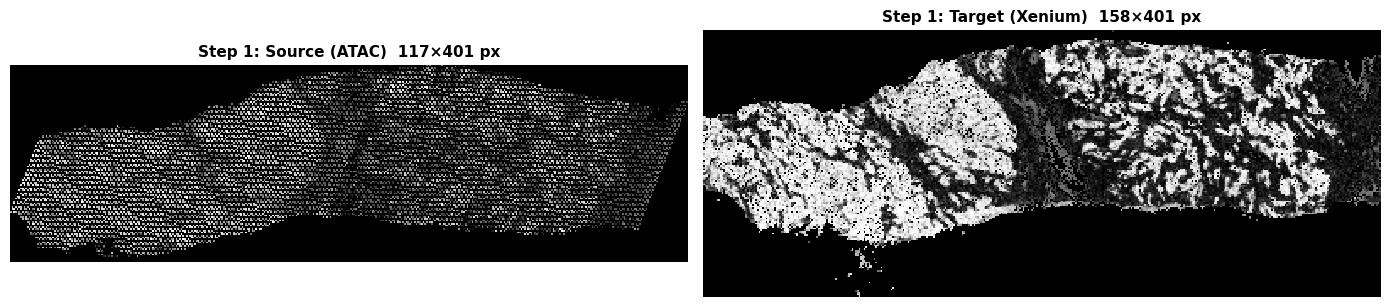

✓ Saved step1_rasterized.png



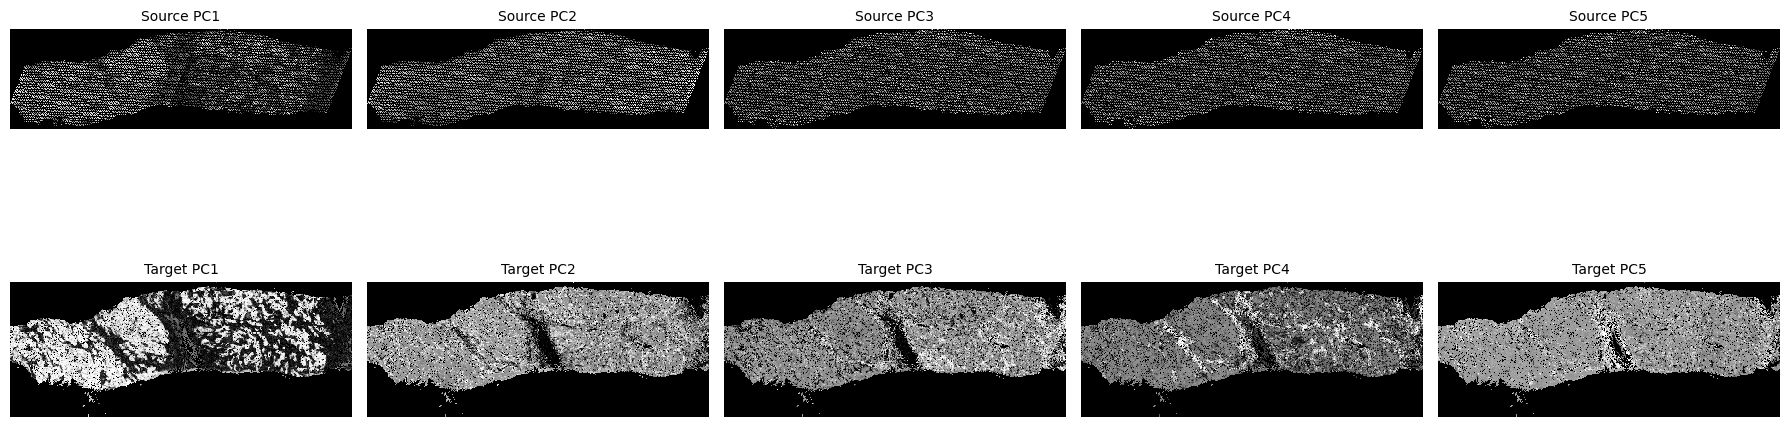

✓ Saved step1_pc_channels.png

Scale factors used — Source: 0.05165, Target: 0.05291


In [9]:
# ============================================================================
# STEP 1: RASTERIZE AFFINE-ALIGNED DATA TO IMAGES
# ============================================================================

print("="*70)
print("STEP 1: Rasterizing to images")
print("="*70 + "\n")

# ---- EXACT original rasterize function — unchanged ----
def rasterize(slice_adata, target_size, translation=None):
    coords = np.asarray(slice_adata.obsm["spatial"], dtype=float)
    x, y = coords[:, 0], coords[:, 1]
    
    if translation is None:
        x_min, y_min = x.min(), y.min()
    else:
        x_min, y_min, x_off, y_off = translation
    x_pix = np.rint(x - x_min).astype(np.int32)
    y_pix = np.rint(y - y_min).astype(np.int32)
    
    W_bb = int(x_pix.max() + 1)
    H_bb = int(y_pix.max() + 1)
    
    target_H, target_W = target_size
    H, W = target_H, target_W
    
    if translation is None:
        H = max(H_bb, target_H)
        W = max(W_bb, target_W)
        x_off = (W - W_bb) // 2
        y_off = (H - H_bb) // 2
    x_pix += x_off
    y_pix += y_off
    
    img = np.zeros((H, W, 50), dtype=np.float32)
    cnt = np.zeros((H, W), dtype=np.int32)
    
    np.add.at(img, (y_pix, x_pix, slice(None)), slice_adata.obsm['X_pca'])
    np.add.at(cnt, (y_pix, x_pix), 1)
    
    mask = cnt > 0
    img[mask] /= cnt[mask][..., None]
    
    img_uint8 = np.zeros_like(img, dtype=np.uint8)
    mask = cnt > 0
    for c in range(img.shape[2]):
        ch = img[..., c]
        if np.any(mask):
            vmin, vmax = ch[mask].min(), ch[mask].max()
            if vmax > vmin:
                ch_norm = np.zeros_like(ch)
                ch_norm[mask] = (ch[mask] - vmin) / (vmax - vmin)
                img_uint8[..., c] = (ch_norm * 255).astype(np.uint8)
    
    slice_adata = slice_adata.copy()
    slice_adata.obsm['spatial'] = np.stack((x_pix, y_pix), axis=1)
    return img_uint8, slice_adata, (x_min, y_min, x_off, y_off)


# ---- Pre-scale: map μm → pixels preserving aspect ratio ----
def scale_spatial_for_rasterize(adata, max_dim=400):
    """
    MOSAICField's rasterize expects pixel-scale coords (no internal scaling).
    Our coords are in micrometers (~8000 × 3000 μm) → need to scale to pixels first.
    max_dim: longest axis in pixels; other axis derived from aspect ratio.
    """
    coords = np.asarray(adata.obsm["spatial"], dtype=float)
    x_span = coords[:, 0].max() - coords[:, 0].min()
    y_span = coords[:, 1].max() - coords[:, 1].min()
    
    scale  = max_dim / max(x_span, y_span)          # scale factor
    target_W = int(np.ceil(x_span * scale))          # preserve aspect ratio
    target_H = int(np.ceil(y_span * scale))
    
    adata_out = adata.copy()
    adata_out.obsm['spatial'] = coords * scale       # scale both axes equally
    
    return adata_out, (target_H, target_W), scale


MAX_DIM = 400   # longest dimension in pixels

print("SOURCE:")
slice_src_scaled, target_size_src, scale_src = scale_spatial_for_rasterize(slice_source, MAX_DIM)
print(f"  Canvas: {target_size_src[0]} H × {target_size_src[1]} W  "
      f"(aspect {target_size_src[1]/target_size_src[0]:.2f}:1)")

print("\nTARGET:")
slice_tgt_scaled, target_size_tgt, scale_tgt = scale_spatial_for_rasterize(slice_target, MAX_DIM)
print(f"  Canvas: {target_size_tgt[0]} H × {target_size_tgt[1]} W  "
      f"(aspect {target_size_tgt[1]/target_size_tgt[0]:.2f}:1)")

# ---- Rasterize ----
img_source_raster, slice_source_rast, trans_src = rasterize(slice_src_scaled, target_size=target_size_src)
img_target_raster, slice_target_rast, trans_tgt = rasterize(slice_tgt_scaled, target_size=target_size_tgt)

src_occ = (img_source_raster.sum(axis=2) > 0)
tgt_occ = (img_target_raster.sum(axis=2) > 0)

print(f"\n✓ Source rasterized: {img_source_raster.shape}  —  {100*src_occ.mean():.1f}% occupied")
print(f"✓ Target rasterized: {img_target_raster.shape}  —  {100*tgt_occ.mean():.1f}% occupied\n")


# ---- Grayscale visualization: PC1 only, contrast-stretched ----
def make_grayscale_vis(img_uint8, channel=0):
    """
    Show a single PCA channel as grayscale.
    Empty pixels stay 0 (black); occupied pixels are contrast-stretched to [1, 255].
    Avoids 'mean of all channels' which flattens to ~127 everywhere.
    """
    gray = img_uint8[..., channel].astype(np.float32)
    occ  = gray > 0                                    # rasterize already normalized; 0 = empty
    vis  = np.zeros_like(gray)
    if occ.any():
        lo = np.percentile(gray[occ], 1)
        hi = np.percentile(gray[occ], 99)
        if hi > lo:
            vis[occ] = np.clip((gray[occ] - lo) / (hi - lo), 0, 1) * 255
        else:
            vis[occ] = 128
    return vis.astype(np.uint8)


# Main side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, img, tag in [
    (axes[0], img_source_raster, f"Source (ATAC)  {img_source_raster.shape[0]}×{img_source_raster.shape[1]} px"),
    (axes[1], img_target_raster, f"Target (Xenium)  {img_target_raster.shape[0]}×{img_target_raster.shape[1]} px"),
]:
    vis = make_grayscale_vis(img, channel=0)
    ax.imshow(vis, cmap='gray', interpolation='nearest')
    ax.set_title(f'Step 1: {tag}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(outdir, 'step1_rasterized.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved step1_rasterized.png\n")


# PC1–PC5 channels for both slices
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for pc in range(5):
    for row, (img, label) in enumerate([(img_source_raster, 'Source'), (img_target_raster, 'Target')]):
        vis = make_grayscale_vis(img, channel=pc)
        axes[row, pc].imshow(vis, cmap='gray', interpolation='nearest')
        axes[row, pc].set_title(f'{label} PC{pc+1}', fontsize=10)
        axes[row, pc].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(outdir, 'step1_pc_channels.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved step1_pc_channels.png\n")

print(f"Scale factors used — Source: {scale_src:.5f}, Target: {scale_tgt:.5f}")

In [25]:
# ============================================================================
# STEP 1 (shared canvas): Rasterize both slices to the SAME H x W
# nonlinear_align requires source and target images of identical shape
# ============================================================================
print("="*70)
print("STEP 1: Rasterize both slices to a shared canvas")
print("="*70 + "\n")

all_src = slice_source.obsm['spatial']
all_tgt = slice_target.obsm['spatial']

x_min_global = min(all_src[:,0].min(), all_tgt[:,0].min())
y_min_global = min(all_src[:,1].min(), all_tgt[:,1].min())
x_max_global = max(all_src[:,0].max(), all_tgt[:,0].max())
y_max_global = max(all_src[:,1].max(), all_tgt[:,1].max())

x_span = x_max_global - x_min_global
y_span = y_max_global - y_min_global

MAX_DIM = 400
scale = MAX_DIM / max(x_span, y_span)
target_W = int(np.ceil(x_span * scale))
target_H = int(np.ceil(y_span * scale))
target_size = (target_H, target_W)

print(f"  Global X span: {x_span:.1f}  Y span: {y_span:.1f}")
print(f"  Scale: {scale:.5f}")
print(f"  Shared canvas: {target_H} H x {target_W} W\n")

def scale_coords(adata, scale, x_min, y_min):
    adata_out = adata.copy()
    coords = np.asarray(adata.obsm['spatial'], dtype=float)
    adata_out.obsm['spatial'] = (coords - np.array([x_min, y_min])) * scale
    return adata_out

slice_src_scaled = scale_coords(slice_source, scale, x_min_global, y_min_global)
slice_tgt_scaled = scale_coords(slice_target, scale, x_min_global, y_min_global)

# Use the SAME (zero) translation for both, so they land on the same canvas
shared_translation = (0.0, 0.0, 0, 0)
img_target_raster, slice_target_rast, trans_tgt = rasterize(slice_tgt_scaled, target_size=target_size, translation=shared_translation)
img_source_raster, slice_source_rast, trans_src = rasterize(slice_src_scaled, target_size=target_size, translation=shared_translation)

assert img_source_raster.shape == img_target_raster.shape, \
    f"Shape mismatch: {img_source_raster.shape} vs {img_target_raster.shape}"

src_occ = (img_source_raster.sum(axis=2) > 0)
tgt_occ = (img_target_raster.sum(axis=2) > 0)
print(f"Source: {img_source_raster.shape}  occupancy: {100*src_occ.mean():.1f}%")
print(f"Target: {img_target_raster.shape}  occupancy: {100*tgt_occ.mean():.1f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, img, title in [
    (axes[0], img_source_raster, f"Source (ATAC) rasterized {img_source_raster.shape[:2]}"),
    (axes[1], img_target_raster, f"Target (Xenium) rasterized {img_target_raster.shape[:2]}"),
]:
    ax.imshow(img.mean(axis=2), cmap='gray', interpolation='nearest')
    ax.set_title(title, fontsize=11, fontweight='bold'); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'step1_rasterized_shared.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved step1_rasterized_shared.png\n")


STEP 1: Rasterize both slices to a shared canvas

  Global X span: 7899.6  Y span: 2970.7
  Scale: 0.05064
  Shared canvas: 151 H x 400 W



IndexError: index 400 is out of bounds for axis 1 with size 400